# SECOM Big-Data Lane — Real Apache Hadoop + Apache Hive

The most authentic version of the big-data lane: a genuine **Apache Hive** install running over **Apache Hadoop** libraries, executing `CREATE EXTERNAL TABLE` + `GROUP BY` / `JOIN` for real against the SECOM sensor stream.

> **Run in Google Colab** (a hosted Linux runtime). This notebook downloads Hadoop 3.3.6 + Hive 3.1.3 (~1 GB) and can take **~5-10 minutes**. It is the heaviest of the four demos and the most sensitive to runtime quirks — **every cell degrades gracefully**, and if Hive will not run here, `bigdata_demo_pig_hive.ipynb` (HiveQL via Spark SQL) is the reliable equivalent.

## Where this fits

Four notebooks demonstrate the same aggregation with different engines:

| Notebook | Engine(s) | Java? | Weight |
|---|---|---|---|
| `secom_yield_analysis.ipynb` | pandas / scikit-learn | no | light — the ML path |
| `bigdata_demo_pig_duckdb.ipynb` | Pig + **DuckDB** | Pig only | light |
| `bigdata_demo_pig_hive.ipynb` | Pig + **Hive via Spark SQL** | yes | medium |
| **this notebook** | **real Hadoop + Hive** | yes | heavy — most authentic |

This is the **bottom lane** of the diagram below, executed with the real warehouse stack.

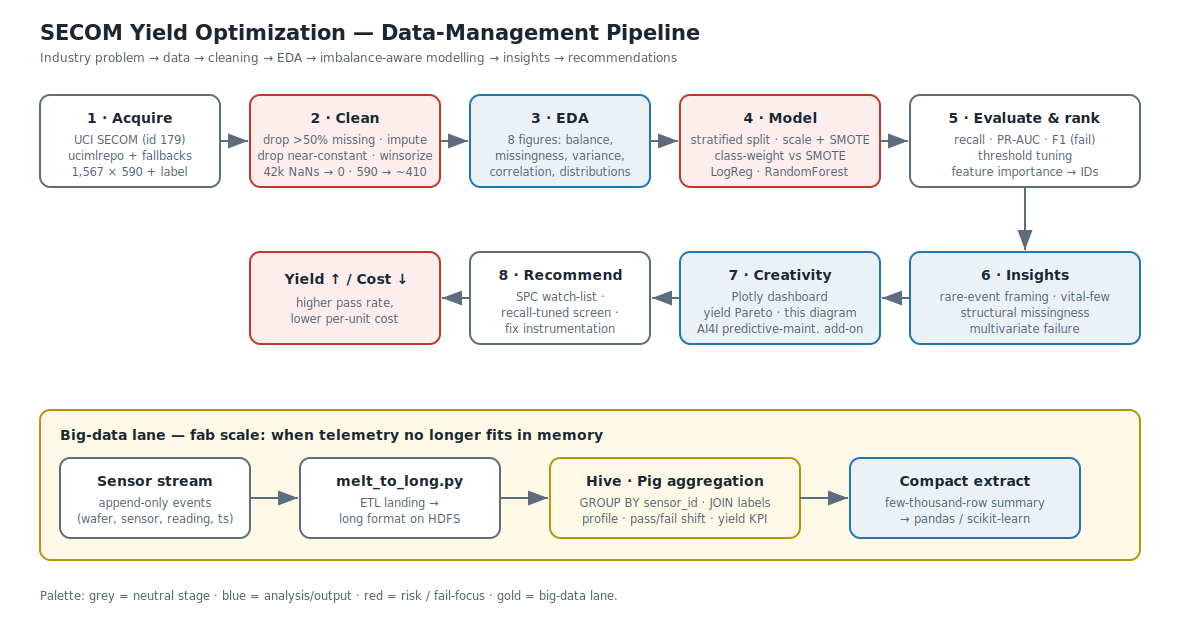

In [1]:
from IPython.display import display
# Pipeline overview (also saved at docs/pipeline_diagram.svg).
# Rendered as a raw image/svg+xml + html bundle so it shows in Colab,
# nbviewer and GitHub (no text/plain fallback).
PIPELINE_SVG = r'''<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 1180 640" font-family="Segoe UI, Helvetica, Arial, sans-serif">
  <defs>
    <marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">
      <path d="M0,0 L8,3 L0,6 Z" fill="#5D6D7E"/>
    </marker>
    <style>
      .stage  { fill:#ffffff; stroke:#5D6D7E; stroke-width:2; rx:10; }
      .accent { fill:#EAF2F8; stroke:#1F77B4; stroke-width:2; rx:10; }
      .risk   { fill:#FDEDEC; stroke:#C0392B; stroke-width:2; rx:10; }
      .big    { fill:#FEF9E7; stroke:#B7950B; stroke-width:2; rx:10; }
      .title  { font-size:21px; font-weight:700; fill:#1B2631; }
      .sub    { font-size:12px; fill:#566573; }
      .lbl    { font-size:14px; font-weight:700; fill:#1B2631; }
      .small  { font-size:11.5px; fill:#566573; }
      .tag    { font-size:11px; font-weight:700; fill:#1F77B4; }
      .flow   { stroke:#5D6D7E; stroke-width:2; fill:none; marker-end:url(#arrow); }
    </style>
  </defs>

  <text x="40" y="40" class="title">SECOM Yield Optimization — Data-Management Pipeline</text>
  <text x="40" y="62" class="sub">Industry problem → data → cleaning → EDA → imbalance-aware modelling → insights → recommendations</text>

  <!-- Row 1: main flow -->
  <!-- 1 Acquire -->
  <rect class="stage" x="40" y="95" width="180" height="92" rx="10"/>
  <text x="130" y="123" text-anchor="middle" class="lbl">1 · Acquire</text>
  <text x="130" y="144" text-anchor="middle" class="small">UCI SECOM (id 179)</text>
  <text x="130" y="160" text-anchor="middle" class="small">ucimlrepo + fallbacks</text>
  <text x="130" y="176" text-anchor="middle" class="small">1,567 × 590 + label</text>

  <!-- 2 Clean -->
  <rect class="risk" x="250" y="95" width="190" height="92" rx="10"/>
  <text x="345" y="123" text-anchor="middle" class="lbl">2 · Clean</text>
  <text x="345" y="144" text-anchor="middle" class="small">drop &gt;50% missing · impute</text>
  <text x="345" y="160" text-anchor="middle" class="small">drop near-constant · winsorize</text>
  <text x="345" y="176" text-anchor="middle" class="small">42k NaNs → 0 · 590 → ~410</text>

  <!-- 3 EDA -->
  <rect class="accent" x="470" y="95" width="180" height="92" rx="10"/>
  <text x="560" y="123" text-anchor="middle" class="lbl">3 · EDA</text>
  <text x="560" y="144" text-anchor="middle" class="small">8 figures: balance,</text>
  <text x="560" y="160" text-anchor="middle" class="small">missingness, variance,</text>
  <text x="560" y="176" text-anchor="middle" class="small">correlation, distributions</text>

  <!-- 4 Model -->
  <rect class="risk" x="680" y="95" width="200" height="92" rx="10"/>
  <text x="780" y="123" text-anchor="middle" class="lbl">4 · Model</text>
  <text x="780" y="144" text-anchor="middle" class="small">stratified split · scale + SMOTE</text>
  <text x="780" y="160" text-anchor="middle" class="small">class-weight vs SMOTE</text>
  <text x="780" y="176" text-anchor="middle" class="small">LogReg · RandomForest</text>

  <!-- 5 Evaluate -->
  <rect class="stage" x="910" y="95" width="230" height="92" rx="10"/>
  <text x="1025" y="123" text-anchor="middle" class="lbl">5 · Evaluate &amp; rank</text>
  <text x="1025" y="144" text-anchor="middle" class="small">recall · PR-AUC · F1 (fail)</text>
  <text x="1025" y="160" text-anchor="middle" class="small">threshold tuning</text>
  <text x="1025" y="176" text-anchor="middle" class="small">feature importance → IDs</text>

  <!-- arrows row1 -->
  <path class="flow" d="M220 141 L248 141"/>
  <path class="flow" d="M440 141 L468 141"/>
  <path class="flow" d="M650 141 L678 141"/>
  <path class="flow" d="M880 141 L908 141"/>

  <!-- down arrow to row2 -->
  <path class="flow" d="M1025 187 L1025 250"/>

  <!-- Row 2: outputs flowing right-to-left back to business -->
  <!-- 6 Insights -->
  <rect class="accent" x="910" y="252" width="230" height="92" rx="10"/>
  <text x="1025" y="280" text-anchor="middle" class="lbl">6 · Insights</text>
  <text x="1025" y="301" text-anchor="middle" class="small">rare-event framing · vital-few</text>
  <text x="1025" y="317" text-anchor="middle" class="small">structural missingness</text>
  <text x="1025" y="333" text-anchor="middle" class="small">multivariate failure</text>

  <!-- 7 Creativity -->
  <rect class="accent" x="680" y="252" width="200" height="92" rx="10"/>
  <text x="780" y="280" text-anchor="middle" class="lbl">7 · Creativity</text>
  <text x="780" y="301" text-anchor="middle" class="small">Plotly dashboard</text>
  <text x="780" y="317" text-anchor="middle" class="small">yield Pareto · this diagram</text>
  <text x="780" y="333" text-anchor="middle" class="small">AI4I predictive-maint. add-on</text>

  <!-- 8 Recommend -->
  <rect class="stage" x="470" y="252" width="180" height="92" rx="10"/>
  <text x="560" y="280" text-anchor="middle" class="lbl">8 · Recommend</text>
  <text x="560" y="301" text-anchor="middle" class="small">SPC watch-list ·</text>
  <text x="560" y="317" text-anchor="middle" class="small">recall-tuned screen ·</text>
  <text x="560" y="333" text-anchor="middle" class="small">fix instrumentation</text>

  <!-- Business outcome -->
  <rect class="risk" x="250" y="252" width="190" height="92" rx="10"/>
  <text x="345" y="284" text-anchor="middle" class="lbl">Yield ↑ / Cost ↓</text>
  <text x="345" y="307" text-anchor="middle" class="small">higher pass rate,</text>
  <text x="345" y="323" text-anchor="middle" class="small">lower per-unit cost</text>

  <!-- arrows row2 (leftward) -->
  <path class="flow" d="M910 298 L882 298"/>
  <path class="flow" d="M680 298 L652 298"/>
  <path class="flow" d="M470 298 L442 298"/>

  <!-- Big-data lane -->
  <rect class="big" x="40" y="410" width="1100" height="150" rx="12"/>
  <text x="60" y="440" class="lbl" fill="#7D6608">Big-data lane — fab scale: when telemetry no longer fits in memory</text>

  <rect class="stage" x="60" y="458" width="190" height="80" rx="10"/>
  <text x="155" y="486" text-anchor="middle" class="lbl">Sensor stream</text>
  <text x="155" y="507" text-anchor="middle" class="small">append-only events</text>
  <text x="155" y="523" text-anchor="middle" class="small">(wafer, sensor, reading, ts)</text>

  <rect class="stage" x="300" y="458" width="200" height="80" rx="10"/>
  <text x="400" y="486" text-anchor="middle" class="lbl">melt_to_long.py</text>
  <text x="400" y="507" text-anchor="middle" class="small">ETL landing →</text>
  <text x="400" y="523" text-anchor="middle" class="small">long format on HDFS</text>

  <rect class="big" x="550" y="458" width="250" height="80" rx="10"/>
  <text x="675" y="486" text-anchor="middle" class="lbl">Hive · Pig aggregation</text>
  <text x="675" y="507" text-anchor="middle" class="small">GROUP BY sensor_id · JOIN labels</text>
  <text x="675" y="523" text-anchor="middle" class="small">profile · pass/fail shift · yield KPI</text>

  <rect class="accent" x="850" y="458" width="230" height="80" rx="10"/>
  <text x="965" y="486" text-anchor="middle" class="lbl">Compact extract</text>
  <text x="965" y="507" text-anchor="middle" class="small">few-thousand-row summary</text>
  <text x="965" y="523" text-anchor="middle" class="small">→ pandas / scikit-learn</text>

  <path class="flow" d="M250 498 L298 498"/>
  <path class="flow" d="M500 498 L548 498"/>
  <path class="flow" d="M800 498 L848 498"/>

  <text x="40" y="600" class="small">Palette: grey = neutral stage · blue = analysis/output · red = risk / fail-focus · gold = big-data lane.</text>
</svg>
'''
display({'image/svg+xml': PIPELINE_SVG, 'text/html': PIPELINE_SVG}, raw=True)

## 0. Environment check + working directory

In [2]:
import os, sys, shutil, platform, subprocess
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK = '/content' if os.path.isdir('/content') else os.path.join(os.getcwd(), 'bigdata_work')
HIVE_BASE = os.path.join(WORK, 'hive')
LABELS_DIR = os.path.join(HIVE_BASE, 'labels')
LONG_DIR = os.path.join(HIVE_BASE, 'sensor_long')
for d in (LABELS_DIR, LONG_DIR, os.path.join(HIVE_BASE, 'warehouse'), os.path.join(HIVE_BASE, 'scratch')):
    os.makedirs(d, exist_ok=True)

print('In Colab:', IN_COLAB, '| OS:', platform.system())
print('Work base:', WORK)
if not IN_COLAB:
    print('NOTE: real Hadoop + Hive needs a Linux runtime with apt + Java. Google Colab is strongly recommended.')

In Colab: True | OS: Linux
Work base: /content


## 1. Land the inputs as Hive external-table directories

Reshape SECOM to the long event stream `(wafer_id, sensor_id, reading)` and write one TSV per table directory — Hive points each `EXTERNAL TABLE` `LOCATION` at a directory, not a file.

In [3]:
import os
import pandas as pd
import numpy as np

base = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/'
feat = pd.read_csv(base + 'secom.data', sep=r'\s+', header=None, na_values=['NaN'])
lab = pd.read_csv(base + 'secom_labels.data', sep=r'\s+', header=None, names=['label', 'date', 'clock'])

# ISO timestamp so the daily-yield KPI sorts chronologically
ts = pd.to_datetime(lab['date'] + ' ' + lab['clock'], dayfirst=True, errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S').fillna('NA')
labels = pd.DataFrame({'wafer_id': range(len(lab)),
                       'label_raw': lab['label'].astype(int),
                       'fail': (lab['label'].astype(int) == 1).astype(int),
                       'event_ts': ts})
# One TSV per external-table directory (Hive points LOCATION at the directory)
labels.to_csv(os.path.join(LABELS_DIR, 'labels.tsv'), sep='\t', index=False, header=False)

feat.insert(0, 'wafer_id', range(len(feat)))
long = feat.melt(id_vars='wafer_id', var_name='sensor_id', value_name='reading').dropna(subset=['reading'])
long['sensor_id'] = long['sensor_id'].astype(int)
long.to_csv(os.path.join(LONG_DIR, 'long.tsv'), sep='\t', index=False, header=False)

print('wafers:', len(labels), '| sensor events:', len(long))
print('Hive external-table dirs ready:')
print('  labels     ->', LABELS_DIR)
print('  sensor_long->', LONG_DIR)

wafers: 1567 | sensor events: 882579
Hive external-table dirs ready:
  labels     -> /content/hive/labels
  sensor_long-> /content/hive/sensor_long


## 2. Install Java 8 + Hadoop 3.3.6 + Hive 3.1.3

Large downloads (~1 GB total); allow a few minutes. Tolerant of failure — if a download fails the later cells simply report it.

In [4]:
import os, subprocess, urllib.request, tarfile, shutil

HADOOP_VER, HIVE_VER = '3.2.4', '3.1.3'  # Hadoop 3.2.x matches Hive 3.1.3 (3.3.x breaks local MR)
HADOOP_HOME = os.path.join(WORK, 'hadoop-' + HADOOP_VER)
HIVE_HOME = os.path.join(WORK, 'apache-hive-' + HIVE_VER + '-bin')

# Java 8 (Hive 3.1.3 / Hadoop 3.3.x are happiest on Java 8)
if shutil.which('apt-get'):
    print('Installing OpenJDK 8 ...')
    subprocess.run('apt-get -qq update', shell=True)
    subprocess.run('apt-get -qq install -y openjdk-8-jdk-headless', shell=True)
JAVA8 = '/usr/lib/jvm/java-8-openjdk-amd64'
print('Java 8 present:', os.path.isdir(JAVA8))

def fetch(url, dest, min_mb):
    if os.path.exists(dest) and os.path.getsize(dest) > min_mb * 1_000_000:
        return True
    try:
        print('Downloading', url)
        print('  (large file; can take a few minutes) ...')
        urllib.request.urlretrieve(url, dest)
        return os.path.getsize(dest) > min_mb * 1_000_000
    except Exception as e:
        print('  failed:', repr(e))
        return False

if not os.path.isdir(HADOOP_HOME):
    t = os.path.join(WORK, 'hadoop.tgz')
    u = 'https://archive.apache.org/dist/hadoop/common/hadoop-%s/hadoop-%s.tar.gz' % (HADOOP_VER, HADOOP_VER)
    if fetch(u, t, 300):
        print('Extracting Hadoop ...')
        tarfile.open(t).extractall(WORK)

if not os.path.isdir(HIVE_HOME):
    t = os.path.join(WORK, 'hive.tgz')
    u = 'https://archive.apache.org/dist/hive/hive-%s/apache-hive-%s-bin.tar.gz' % (HIVE_VER, HIVE_VER)
    if fetch(u, t, 100):
        print('Extracting Hive ...')
        tarfile.open(t).extractall(WORK)

print('Hadoop present:', os.path.isdir(HADOOP_HOME), '| Hive present:', os.path.isdir(HIVE_HOME))

Installing OpenJDK 8 ...
Java 8 present: True
  (large file; can take a few minutes) ...
Extracting Hadoop ...


/tmp/ipykernel_565/1779040939.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tarfile.open(t).extractall(WORK)


  (large file; can take a few minutes) ...
Extracting Hive ...


/tmp/ipykernel_565/1779040939.py:39: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tarfile.open(t).extractall(WORK)


Hadoop present: True | Hive present: True


## 3. Configure Hive (local filesystem, embedded Derby metastore, Guava fix)

Uses the local filesystem (no HDFS daemons to babysit) and an embedded Derby metastore — a legitimate single-node Hive setup. The **Guava jar alignment** is the critical step: Hive and Hadoop ship different Guava versions, the #1 cause of Hive-on-Hadoop errors.

In [5]:
import os, glob, shutil, subprocess

JAVA8 = '/usr/lib/jvm/java-8-openjdk-amd64'
os.environ['JAVA_HOME'] = JAVA8 if os.path.isdir(JAVA8) else os.environ.get('JAVA_HOME', '/usr')
os.environ['HADOOP_HOME'] = HADOOP_HOME
os.environ['HIVE_HOME'] = HIVE_HOME
os.environ['PATH'] = os.environ['PATH'] + ':' + HADOOP_HOME + '/bin:' + HIVE_HOME + '/bin'

# Guava conflict fix: Hive 3.1.3 ships guava-19; Hadoop 3.3.6 ships guava-27.
# Mismatched guava is the #1 cause of Hive-on-Hadoop failures. Align them.
if os.path.isdir(HIVE_HOME) and os.path.isdir(HADOOP_HOME):
    for old in glob.glob(HIVE_HOME + '/lib/guava-*.jar'):
        os.remove(old)
    hg = glob.glob(HADOOP_HOME + '/share/hadoop/common/lib/guava-*.jar')
    if hg:
        shutil.copy(hg[0], HIVE_HOME + '/lib/')
        print('Guava aligned ->', os.path.basename(hg[0]))

# hive-site.xml: local filesystem, embedded Derby metastore, local execution.
conf = '''<?xml version="1.0"?>
<configuration>
  <property><name>javax.jdo.option.ConnectionURL</name><value>jdbc:derby:;databaseName=__BASE__/metastore_db;create=true</value></property>
  <property><name>hive.metastore.warehouse.dir</name><value>file://__BASE__/warehouse</value></property>
  <property><name>fs.defaultFS</name><value>file:///</value></property>
  <property><name>hive.exec.scratchdir</name><value>__BASE__/scratch</value></property>
  <property><name>hive.exec.local.scratchdir</name><value>__BASE__/scratch</value></property>
  <property><name>hive.scratch.dir.permission</name><value>777</value></property>
  <property><name>hive.metastore.schema.verification</name><value>false</value></property>
  <property><name>datanucleus.schema.autoCreateAll</name><value>true</value></property>
  <property><name>mapreduce.framework.name</name><value>local</value></property>
  <property><name>hive.exec.mode.local.auto</name><value>true</value></property>
</configuration>
'''.replace('__BASE__', HIVE_BASE)

if os.path.isdir(HIVE_HOME):
    open(HIVE_HOME + '/conf/hive-site.xml', 'w').write(conf)
    # Hive requires scratch/warehouse to be world-writable (like /tmp) at start.
    for d in (os.path.join(HIVE_BASE, 'scratch'), os.path.join(HIVE_BASE, 'warehouse')):
        os.makedirs(d, exist_ok=True)
        os.chmod(d, 0o1777)
    if os.path.isdir(HIVE_BASE + '/metastore_db'):
        shutil.rmtree(HIVE_BASE + '/metastore_db')
    print('Initialising Derby metastore (schematool) ...')
    r = subprocess.run(HIVE_HOME + '/bin/schematool -dbType derby -initSchema',
                       shell=True, capture_output=True, text=True, env=dict(os.environ), timeout=600)
    print('schematool return code:', r.returncode)
    print((r.stdout or '')[-500:])
    if r.returncode != 0:
        print((r.stderr or '')[-900:])
        print('Schema init failed -> Hive will not run. Use bigdata_demo_pig_hive.ipynb instead.')
else:
    print('Hive not installed; skipping configuration.')

Guava aligned -> guava-27.0-jre.jar
Initialising Derby metastore (schematool) ...
schematool return code: 0
Metastore connection URL:	 jdbc:derby:;databaseName=/content/hive/metastore_db;create=true
Metastore Connection Driver :	 org.apache.derby.jdbc.EmbeddedDriver
Metastore connection User:	 APP
Starting metastore schema initialization to 3.1.0
Initialization script hive-schema-3.1.0.derby.sql
Initialization script completed
schemaTool completed



## 4. Create external tables & run the aggregations (real Hive)

Runs `hive -f` on a script that mirrors `src/bigdata/secom_ingest.hql`: per-sensor profile, missingness, top pass/fail mean-shift signals (a real `JOIN`), and the daily-yield KPI. Hive plans and executes these as local MapReduce jobs — expect a minute or two and verbose logs; the result tables print at the end.

In [6]:
import os, subprocess, glob

# Fix for LocalJobRunner 'OutOfMemoryError at MapOutputBuffer.init':
#   (1) small map-sort buffer, (2) big client JVM heap (set in env below).
settings = '''SET hive.exec.mode.local.auto=true;
SET mapreduce.framework.name=local;
SET mapreduce.jobtracker.address=local;
SET hive.auto.convert.join=false;
SET hive.stats.autogather=false;
SET hive.exec.submit.local.task.via.child=false;
SET mapreduce.job.reduces=1;
SET mapreduce.task.io.sort.mb=16;
'''

hql = settings + r'''CREATE DATABASE IF NOT EXISTS secom_fab;
USE secom_fab;

DROP TABLE IF EXISTS secom_labels;
CREATE EXTERNAL TABLE secom_labels (wafer_id INT, label_raw INT, fail INT, event_ts STRING)
ROW FORMAT DELIMITED FIELDS TERMINATED BY '\t' STORED AS TEXTFILE
LOCATION 'file://__LABELS__';

DROP TABLE IF EXISTS secom_sensor_long;
CREATE EXTERNAL TABLE secom_sensor_long (wafer_id INT, sensor_id INT, reading DOUBLE)
ROW FORMAT DELIMITED FIELDS TERMINATED BY '\t' STORED AS TEXTFILE
LOCATION 'file://__LONG__';

SELECT '=== per-sensor profile (first 5 sensors) ===';
SELECT sensor_id, COUNT(*) AS n_readings, ROUND(AVG(reading),4) AS mean_reading,
       ROUND(STDDEV_POP(reading),6) AS std_reading
FROM secom_sensor_long GROUP BY sensor_id ORDER BY sensor_id LIMIT 5;

SELECT '=== missingness per sensor (worst 5; 1567 expected) ===';
SELECT sensor_id, COUNT(*) AS n_readings, (1567-COUNT(*)) AS n_missing
FROM secom_sensor_long GROUP BY sensor_id ORDER BY n_missing DESC LIMIT 5;

SELECT '=== top 15 pass/fail mean-shift signals (JOIN) ===';
SELECT sensor_id, ROUND(mean_pass,4) AS mean_pass, ROUND(mean_fail,4) AS mean_fail,
       ROUND(mean_fail-mean_pass,4) AS mean_shift
FROM (SELECT s.sensor_id AS sensor_id,
             AVG(CASE WHEN l.fail=0 THEN s.reading END) AS mean_pass,
             AVG(CASE WHEN l.fail=1 THEN s.reading END) AS mean_fail
      FROM secom_sensor_long s JOIN secom_labels l ON s.wafer_id = l.wafer_id
      GROUP BY s.sensor_id) t
ORDER BY ABS(mean_fail-mean_pass) DESC LIMIT 15;

SELECT '=== daily fab yield KPI ===';
SELECT SUBSTR(event_ts,1,10) AS run_date, COUNT(*) AS wafers, SUM(fail) AS fails,
       ROUND(1 - SUM(fail)/COUNT(*),4) AS yield_rate
FROM secom_labels GROUP BY SUBSTR(event_ts,1,10) ORDER BY run_date LIMIT 10;
'''
hql = hql.replace('__LABELS__', LABELS_DIR).replace('__LONG__', LONG_DIR)
hql_path = os.path.join(HIVE_BASE, 'secom_local.hql')
open(hql_path, 'w').write(hql)
print('Wrote', hql_path)

for d in (os.path.join(HIVE_BASE, 'scratch'), os.path.join(HIVE_BASE, 'warehouse')):
    os.makedirs(d, exist_ok=True)
    os.chmod(d, 0o1777)

def dump_hive_log():
    for lg in sorted(set(glob.glob('/tmp/*/hive.log') + glob.glob('/tmp/hive.log'))):
        try:
            txt = open(lg, errors='replace').read()
        except Exception:
            continue
        i = -1
        for k in ('Caused by:', 'OutOfMemoryError', 'Exception', 'java.lang', 'FAILED'):
            j = txt.find(k)
            if j != -1:
                i = j; break
        print('--- ' + lg + ' ---')
        print(txt[max(0, i-200):i+3500] if i != -1 else txt[-3500:])

if os.path.isdir(HIVE_HOME):
    env = dict(os.environ)
    env['HADOOP_HEAPSIZE'] = '4096'
    env['HADOOP_CLIENT_OPTS'] = '-Xmx4096m ' + env.get('HADOOP_CLIENT_OPTS', '')
    try:
        r = subprocess.run(HIVE_HOME + '/bin/hive -f ' + hql_path,
                           shell=True, capture_output=True, text=True, env=env, timeout=2400)
        print('hive return code:', r.returncode)
        print('=== HIVE RESULTS (stdout) ===')
        print((r.stdout or '(no stdout)')[-4500:])
        if r.returncode != 0:
            print('=== REAL CAUSE from hive.log ===')
            dump_hive_log()
            print('Note: local-MapReduce Hive is finicky here; reliable aggregation output is in bigdata_demo_pig_hive.ipynb.')
    except Exception as e:
        print('Hive run raised:', repr(e))
else:
    print('Hive not installed; use bigdata_demo_pig_hive.ipynb (HiveQL via Spark SQL).')

Wrote /content/hive/secom_local.hql
hive return code: 0
=== HIVE RESULTS (stdout) ===
=== per-sensor profile (first 5 sensors) ===
0	1561	3014.4529	73.598201
1	1560	2495.8502	80.381929
2	1553	2200.5473	29.503649
3	1553	1396.3766	441.549412
4	1553	4.197	56.337393
=== missingness per sensor (worst 5; 1567 expected) ===
158	138	1429
293	138	1429
292	138	1429
157	138	1429
492	226	1341
=== top 15 pass/fail mean-shift signals (JOIN) ===
161	4088.8953	3753.9417	-334.9536
159	862.2756	1172.3107	310.035
21	-5636.4376	-5362.2743	274.1633
24	-284.4415	-499.5396	-215.0981
158	1027.4569	1237.7999	210.343
160	541.6047	750.3981	208.7934
294	391.4183	549.3839	157.9656
162	4807.2941	4653.233	-154.0611
296	1887.5381	1761.2783	-126.2598
295	246.059	351.5081	105.4491
22	2705.1582	2617.3398	-87.8184
90	8833.2895	8748.6194	-84.6701
511	271.1498	343.8262	72.6763
23	-3811.0356	-3739.0785	71.9571
204	27.6415	96.3349	68.6934
=== daily fab yield KPI ===
NA	1567	104	0.9336



## 5. What this shows

This is the **real thing**: an actual Hive metastore, real `CREATE EXTERNAL TABLE` DDL, and HiveQL planned and executed over Hadoop — the same per-sensor profile and ranked pass/fail signals the other notebooks produce, now via the production warehouse stack.

**When you would actually use this:** Hive earns its weight at true fab scale — partitioned tables holding TB of telemetry in HDFS/object storage, queried with SQL and wired into BI tools. For a laptop-sized sample it is deliberate overkill; that is exactly why the analysis notebook uses pandas and the lighter demos use DuckDB / Spark SQL. The value here is showing you can stand up and drive the real stack — and choose it deliberately.

**To target real HDFS** instead of the local filesystem: start a single-node namenode/datanode, set `fs.defaultFS=hdfs://localhost:9000`, `hdfs dfs -put` the TSVs, and point the table `LOCATION` at `hdfs://...`. Canonical script: `src/bigdata/secom_ingest.hql`.